In [1]:
import pandas as pd

# Load the dataset, limiting to 50,000 rows for faster processing
df = pd.read_csv(
    "household_power_consumption.txt",
    sep=';',
    low_memory=False,
    na_values=['?'],
    nrows=50000
)


display(df.head())

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [2]:
# Cell 2: Imports & Logging Configuration
from __future__ import annotations

import logging
import pickle
import warnings
from pathlib import Path
from typing import List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler

warnings.filterwarnings("ignore")


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  [%(levelname)s]  %(name)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("UCIPipeline")

print("✅ Imports and logging setup complete!")

✅ Imports and logging setup complete!


In [3]:
# Cell 3: Data Engineer Layer
class UCIDataIngester:
    RAW_COLS = [
        "Date", "Time", "Global_active_power", "Global_reactive_power",
        "Voltage", "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3",
    ]

    def __init__(self, filepath: str | Path, nrows: Optional[int] = None) -> None:
        self.filepath = Path(filepath)
        self.nrows = nrows

    def load(self) -> pd.DataFrame:
        print(f"⏳ [Step 1] Ingesting file: {self.filepath}...")
        df = pd.read_csv(
            self.filepath, sep=";", header=0, names=self.RAW_COLS,
            na_values="?", low_memory=False, nrows=self.nrows,
        )

        df["datetime"] = pd.to_datetime(
            df["Date"] + " " + df["Time"], format="%d/%m/%Y %H:%M:%S",
        )
        df = df.drop(columns=["Date", "Time"]).set_index("datetime")
        df = df.sort_index()

        full_idx = pd.date_range(df.index.min(), df.index.max(), freq="1min")
        df = df.reindex(full_idx)
        df.index.name = "datetime"

        numeric_cols = df.columns.tolist()
        df[numeric_cols] = df[numeric_cols].astype("float32")
        print(f"✅ Ingestion complete! Loaded {len(df)} rows.")
        return df

class PhysicalValidator(BaseEstimator, TransformerMixin):
    def __init__(self, v_min: float = 220.0, v_max: float = 255.0, drop_voltage_outliers: bool = False) -> None:
        self.v_min = v_min
        self.v_max = v_max
        self.drop_voltage_outliers = drop_voltage_outliers

    def fit(self, X: pd.DataFrame, y=None) -> "PhysicalValidator":
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        print("⏳ [Step 2] Applying physical validation checks...")
        df = X.copy()

        # Negative active power → NaN
        neg_mask = df["Global_active_power"] < 0
        df.loc[neg_mask, "Global_active_power"] = np.nan

        # Voltage stability
        v_mask = (df["Voltage"] < self.v_min) | (df["Voltage"] > self.v_max)
        if self.drop_voltage_outliers and v_mask.sum():
            df.loc[v_mask, "Voltage"] = np.nan

        # Remainder energy
        df["E_rem"] = (
            df["Global_active_power"] * (1000.0 / 60.0)
            - df["Sub_metering_1"] - df["Sub_metering_2"] - df["Sub_metering_3"]
        ).astype("float32")

        print("✅ Physical validation complete. Added 'E_rem' column.")
        return df

In [4]:
# Cell 4: Data Scientist Layer - Imputation
class HierarchicalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, short_threshold: int = 30) -> None:
        self.short_threshold = short_threshold
        self.seasonal_means_: Optional[pd.DataFrame] = None

    def fit(self, X: pd.DataFrame, y=None) -> "HierarchicalImputer":
        print("⏳ [Step 3] Fitting Hierarchical Imputer (calculating seasonal means)...")
        key = pd.MultiIndex.from_arrays([X.index.hour, X.index.weekday], names=["hour", "weekday"])
        tmp = X.copy()
        tmp.index = key
        self.seasonal_means_ = tmp.groupby(level=["hour", "weekday"]).mean()
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        print("⏳ [Step 4] Imputing missing values...")
        df = X.copy()
        for col in df.columns:
            series = df[col]
            if series.isna().sum() == 0: continue

            null_mask = series.isna()
            run_id = null_mask.ne(null_mask.shift()).cumsum()
            run_lengths = null_mask.groupby(run_id).transform("sum")

            short_mask = null_mask & (run_lengths < self.short_threshold)
            long_mask  = null_mask & (run_lengths >= self.short_threshold)

            if short_mask.any():
                series = series.copy()
                series = series.interpolate(method="cubic", limit=self.short_threshold - 1, limit_direction="both")

            if long_mask.any():
                sm = self.seasonal_means_[col]
                for idx in series.index[series.isna()]:
                    key = (idx.hour, idx.weekday())
                    fill_val = sm.loc[key] if key in sm.index else sm.mean()
                    series.at[idx] = fill_val

            df[col] = series

        df = df.ffill().bfill()
        print("✅ Imputation complete.")
        return df.astype("float32")

In [5]:
# Cell 5: Data Scientist Layer - Feature Engineering
class CyclicalEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X: pd.DataFrame, y=None) -> "CyclicalEncoder": return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        print("⏳ [Step 5] Adding cyclical time features (sin/cos)...")
        df = X.copy()
        idx = df.index

        def _sin_cos(val: np.ndarray, period: float):
            angle = 2 * np.pi * val / period
            return np.sin(angle), np.cos(angle)

        df["hour_sin"], df["hour_cos"] = _sin_cos(idx.hour, 24)
        df["month_sin"], df["month_cos"] = _sin_cos(idx.month - 1, 12)
        df["weekday_sin"], df["weekday_cos"] = _sin_cos(idx.weekday, 7)
        df["minute_sin"], df["minute_cos"] = _sin_cos(idx.hour * 60 + idx.minute, 1440)

        return df.astype("float32")

class LagAndRollingFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, lag_cols=None, lags=None, roll_windows=None) -> None:
        self.lag_cols = lag_cols or ["Global_active_power", "Global_reactive_power", "Voltage", "Global_intensity", "E_rem"]
        self.lags = lags or [1, 60, 1440]
        self.roll_windows = roll_windows or [60, 1440]

    def fit(self, X: pd.DataFrame, y=None) -> "LagAndRollingFeatureEngineer":
        self.lag_cols = [c for c in self.lag_cols if c in X.columns]
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        print("⏳ [Step 6] Engineering lag and rolling window features...")
        df = X.copy()
        new_cols = {}

        for col in self.lag_cols:
            series = df[col]
            for lag in self.lags:
                new_cols[f"{col}_lag{lag}"] = series.shift(lag).values
            for win in self.roll_windows:
                roll = series.rolling(window=win, min_periods=1)
                new_cols[f"{col}_roll{win}m_mean"] = roll.mean().values
                new_cols[f"{col}_roll{win}m_std"]  = roll.std().values

        new_df = pd.DataFrame(new_cols, index=df.index, dtype="float32")
        df = pd.concat([df, new_df], axis=1)
        print(f"✅ Feature engineering complete. Total columns now: {df.shape[1]}")
        return df

In [6]:
# Cell 6: ML Engineer Layer - Scaling & Guards
class DataFrameScaler(BaseEstimator, TransformerMixin):
    def __init__(self, power_cols=None, voltage_cols=None) -> None:
        self.power_cols = power_cols
        self.voltage_cols = voltage_cols

    def _build_ct(self, all_cols: List[str]) -> ColumnTransformer:
        power_cols = self.power_cols or []
        voltage_cols = self.voltage_cols or []
        other_cols = [c for c in all_cols if c not in power_cols and c not in voltage_cols]

        transformers = []
        if power_cols: transformers.append(("minmax", MinMaxScaler(), power_cols))
        if voltage_cols: transformers.append(("stdscaler", StandardScaler(), voltage_cols))
        if other_cols: transformers.append(("passthrough", "passthrough", other_cols))

        return ColumnTransformer(transformers=transformers, remainder="drop")

    def fit(self, X: pd.DataFrame, y=None) -> "DataFrameScaler":
        print("⏳ [Step 7] Fitting Scalers (MinMax for power, StandardScaler for voltage)...")
        self._ct = self._build_ct(X.columns.tolist())
        self._ct.fit(X)

        names = []
        for name, trans, cols in self._ct.transformers_:
            if trans != "drop": names.extend(cols)
        self._output_cols = names
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        arr = self._ct.transform(X)
        return pd.DataFrame(arr, index=X.index, columns=self._output_cols, dtype="float32")

class FinalNaNGuard(BaseEstimator, TransformerMixin):
    def fit(self, X: pd.DataFrame, y=None) -> "FinalNaNGuard": return self
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        df = X.replace([np.inf, -np.inf], np.nan)
        if df.isna().sum().sum():
            df = df.fillna(0.0)
        return df.astype("float32")

In [7]:
# Cell 7: Top-Level Orchestrator
class UCIPreprocessor:
    POWER_COLS_BASE = [
        "Global_active_power", "Global_reactive_power", "Global_intensity",
        "Sub_metering_1", "Sub_metering_2", "Sub_metering_3", "E_rem",
    ]
    VOLTAGE_COLS_BASE = ["Voltage"]

    def __init__(self, filepath: str | Path, nrows: Optional[int] = None, short_gap_threshold: int = 30, test_ratio: float = 0.2) -> None:
        self.filepath = Path(filepath)
        self.nrows = nrows
        self.short_gap_threshold = short_gap_threshold
        self.test_ratio = test_ratio

    def _build_pipeline(self) -> Pipeline:
        lag_eng = LagAndRollingFeatureEngineer()
        power_cols_full = (
            self.POWER_COLS_BASE
            + [f"{c}_lag{l}" for c in lag_eng.lag_cols for l in lag_eng.lags]
            + [f"{c}_roll{w}m_mean" for c in lag_eng.lag_cols for w in lag_eng.roll_windows]
            + [f"{c}_roll{w}m_std" for c in lag_eng.lag_cols for w in lag_eng.roll_windows]
        )

        return Pipeline(steps=[
            ("imputer", HierarchicalImputer(short_threshold=self.short_gap_threshold)),
            ("cyclical", CyclicalEncoder()),
            ("lag_feats", lag_eng),
            ("scaler", DataFrameScaler(power_cols=power_cols_full, voltage_cols=self.VOLTAGE_COLS_BASE)),
            ("nan_guard", FinalNaNGuard()),
        ])

    def fit_transform_split(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        raw = UCIDataIngester(self.filepath, nrows=self.nrows).load()
        validated = PhysicalValidator().transform(raw) # Fit is a no-op

        split_idx = int(len(validated) * (1 - self.test_ratio))
        train_raw, test_raw = validated.iloc[:split_idx], validated.iloc[split_idx:]
        print(f"\n✂️ Splitting data... Train: {len(train_raw)} rows, Test: {len(test_raw)} rows.")

        self._pipeline = self._build_pipeline()

        print("\n🚀 --- PROCESSING TRAINING DATA ---")
        X_train = self._pipeline.fit_transform(train_raw)

        print("\n🚀 --- PROCESSING TEST DATA ---")
        X_test = self._pipeline.transform(test_raw)

        return X_train, X_test

    def save(self, output_path: str) -> None:
        joblib.dump(self._pipeline, output_path)
        print(f"💾 Pipeline saved to {output_path}")

    @staticmethod
    def load(path: str) -> Pipeline: return joblib.load(path)

In [8]:
# Cell 8: Main Execution Block
FILEPATH = "household_power_consumption.txt"
NROWS = 50_000
SAVE_PATH = "uci_power_pipeline.joblib"

print("🌟 Starting UCI Household Power Preprocessing Pipeline...\n")

preprocessor = UCIPreprocessor(filepath=FILEPATH, nrows=NROWS)
X_train, X_test = preprocessor.fit_transform_split()

preprocessor.save(SAVE_PATH)

print("\n" + "="*60)
print("🎯 PIPELINE SUMMARY")
print(f"   Train shape   : {X_train.shape}")
print(f"   Test shape    : {X_test.shape}")
print(f"   NaN in train  : {X_train.isna().sum().sum()}")
print(f"   NaN in test   : {X_test.isna().sum().sum()}")
print("="*60 + "\n")

print("Here is a peek at the fully processed Training dataset:")

display(X_train.head())

🌟 Starting UCI Household Power Preprocessing Pipeline...

⏳ [Step 1] Ingesting file: household_power_consumption.txt...
✅ Ingestion complete! Loaded 50000 rows.
⏳ [Step 2] Applying physical validation checks...
✅ Physical validation complete. Added 'E_rem' column.

✂️ Splitting data... Train: 40000 rows, Test: 10000 rows.

🚀 --- PROCESSING TRAINING DATA ---
⏳ [Step 3] Fitting Hierarchical Imputer (calculating seasonal means)...
⏳ [Step 4] Imputing missing values...
✅ Imputation complete.
⏳ [Step 5] Adding cyclical time features (sin/cos)...
⏳ [Step 6] Engineering lag and rolling window features...
✅ Feature engineering complete. Total columns now: 51
⏳ [Step 7] Fitting Scalers (MinMax for power, StandardScaler for voltage)...

🚀 --- PROCESSING TEST DATA ---
⏳ [Step 4] Imputing missing values...
✅ Imputation complete.
⏳ [Step 5] Adding cyclical time features (sin/cos)...
⏳ [Step 6] Engineering lag and rolling window features...
✅ Feature engineering complete. Total columns now: 51
💾 Pip

,Global_active_power,Global_reactive_power,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,E_rem,Global_active_power_lag1,Global_active_power_lag60,Global_active_power_lag1440,...,E_rem_roll1440m_std,Voltage,hour_sin,hour_cos,month_sin,month_cos,weekday_sin,weekday_cos,minute_sin,minute_cos
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-16 17:24:00,0.449989,0.484919,0.455958,0.0,0.013333,0.85,0.413840,0.000000,0.0,0.0,...,0.000000,-1.743334,-0.965926,-0.258819,-0.5,0.866025,-0.974928,-0.222521,-0.987688,-0.156434
2006-12-16 17:25:00,0.577982,0.505800,0.575130,0.0,0.013333,0.80,0.575929,0.449989,0.0,0.0,...,0.659446,-2.075974,-0.965926,-0.258819,-0.5,0.866025,-0.974928,-0.222521,-0.988362,-0.152123
2006-12-16 17:26:00,0.579548,0.577726,0.575130,0.0,0.026667,0.85,0.561659,0.577982,0.0,0.0,...,0.501763,-2.169447,-0.965926,-0.258819,-0.5,0.866025,-0.974928,-0.222521,-0.989016,-0.147809
2006-12-16 17:27:00,0.581114,0.582367,0.575130,0.0,0.013333,0.85,0.571621,0.579548,0.0,0.0,...,0.428399,-2.045733,-0.965926,-0.258819,-0.5,0.866025,-0.974928,-0.222521,-0.989651,-0.143493
2006-12-16 17:28:00,0.388454,0.612529,0.388601,0.0,0.013333,0.85,0.339795,0.581114,0.0,0.0,...,0.623740,-1.512410,-0.965926,-0.258819,-0.5,0.866025,-0.974928,-0.222521,-0.990268,-0.139173


In [9]:
df.shape

(50000, 9)

In [10]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
# Cell 1: Imports and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("muted")


df = pd.read_csv('household_power_consumption.txt', sep=';', na_values=['?'], low_memory=False)

# Combine Date and Time into a single Datetime column and set as index
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('Datetime', inplace=True)
df.drop(['Date', 'Time'], axis=1, inplace=True)

# Convert all columns to numeric (just in case)
df = df.apply(pd.to_numeric, errors='coerce')

print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (162495, 7)


--- Phase 1: Data Understanding ---
Shape: 162495 rows, 7 columns

Data Types:
 Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object 

Missing Values Summary:
                        Missing Values  Percentage (%)
Global_active_power                 9        0.005539
Global_reactive_power              10        0.006154
Voltage                            10        0.006154
Global_intensity                   10        0.006154
Sub_metering_1                     10        0.006154
Sub_metering_2                     10        0.006154
Sub_metering_3                     10        0.006154 

Duplicate Records: 7974

Memory Usage: 9.92 MB



,count,mean,std,min,25%,50%,75%,max
Global_active_power,162486.0,1.482557,1.320188,0.194,0.332,1.326,2.282,10.670
Global_reactive_power,162485.0,0.122080,0.114042,0.000,0.000,0.106,0.188,0.874
Voltage,162485.0,240.749823,3.251823,223.490,238.680,240.970,242.990,251.700
Global_intensity,162485.0,6.266821,5.574221,0.800,1.400,5.400,9.400,46.400
Sub_metering_1,162485.0,1.279546,6.585609,0.000,0.000,0.000,0.000,77.000
Sub_metering_2,162485.0,1.959129,7.581728,0.000,0.000,0.000,1.000,78.000
Sub_metering_3,162485.0,7.006234,8.577437,0.000,0.000,0.000,17.000,20.000


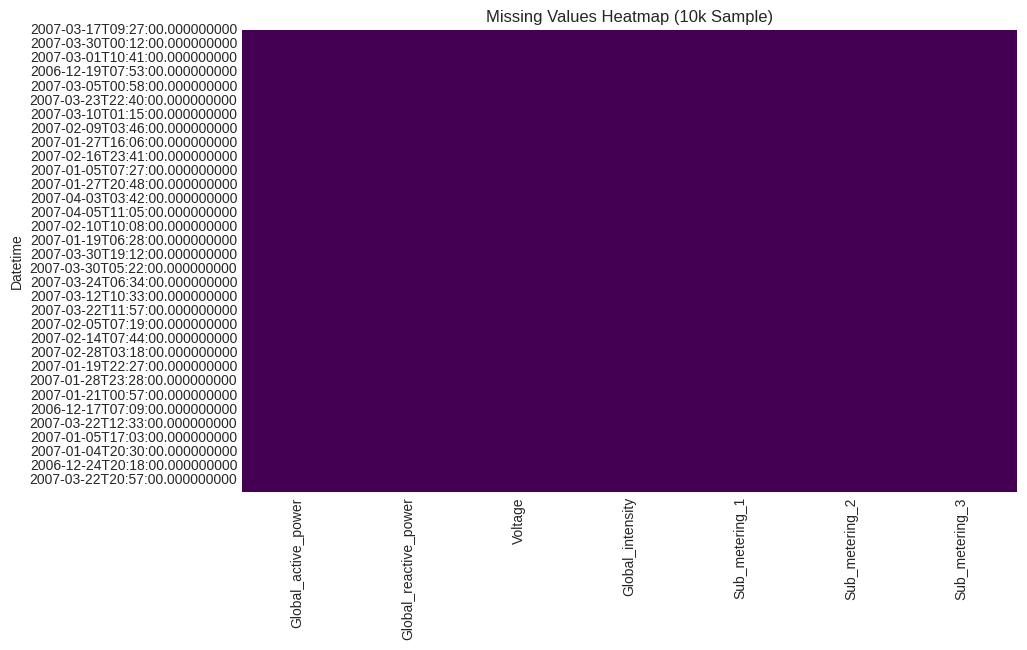

In [12]:
# Cell 2: Data Understanding
print("--- Phase 1: Data Understanding ---")

# 1. Dataset shape
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# 2. Data types
print("Data Types:\n", df.dtypes, "\n")

# 3. Missing values analysis
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percent})
print("Missing Values Summary:\n", missing_df[missing_df['Missing Values'] > 0], "\n")

# 4. Duplicate records
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates}\n")

# 5. Memory usage
print(f"Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB\n")

# 6. Statistical summary
display(df.describe().T)

# Visualization: Missing value heatmap (Using a sample for memory efficiency)
plt.figure(figsize=(10, 6))
sns.heatmap(df.sample(10000).isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (10k Sample)')
plt.show()

--- Phase 2: Time Series Structure Analysis ---
Start Date: 2006-12-16 17:24:00
End Date: 2007-04-08 13:38:00
Time Granularity: 0 days 00:01:00
Missing Timestamps: 0


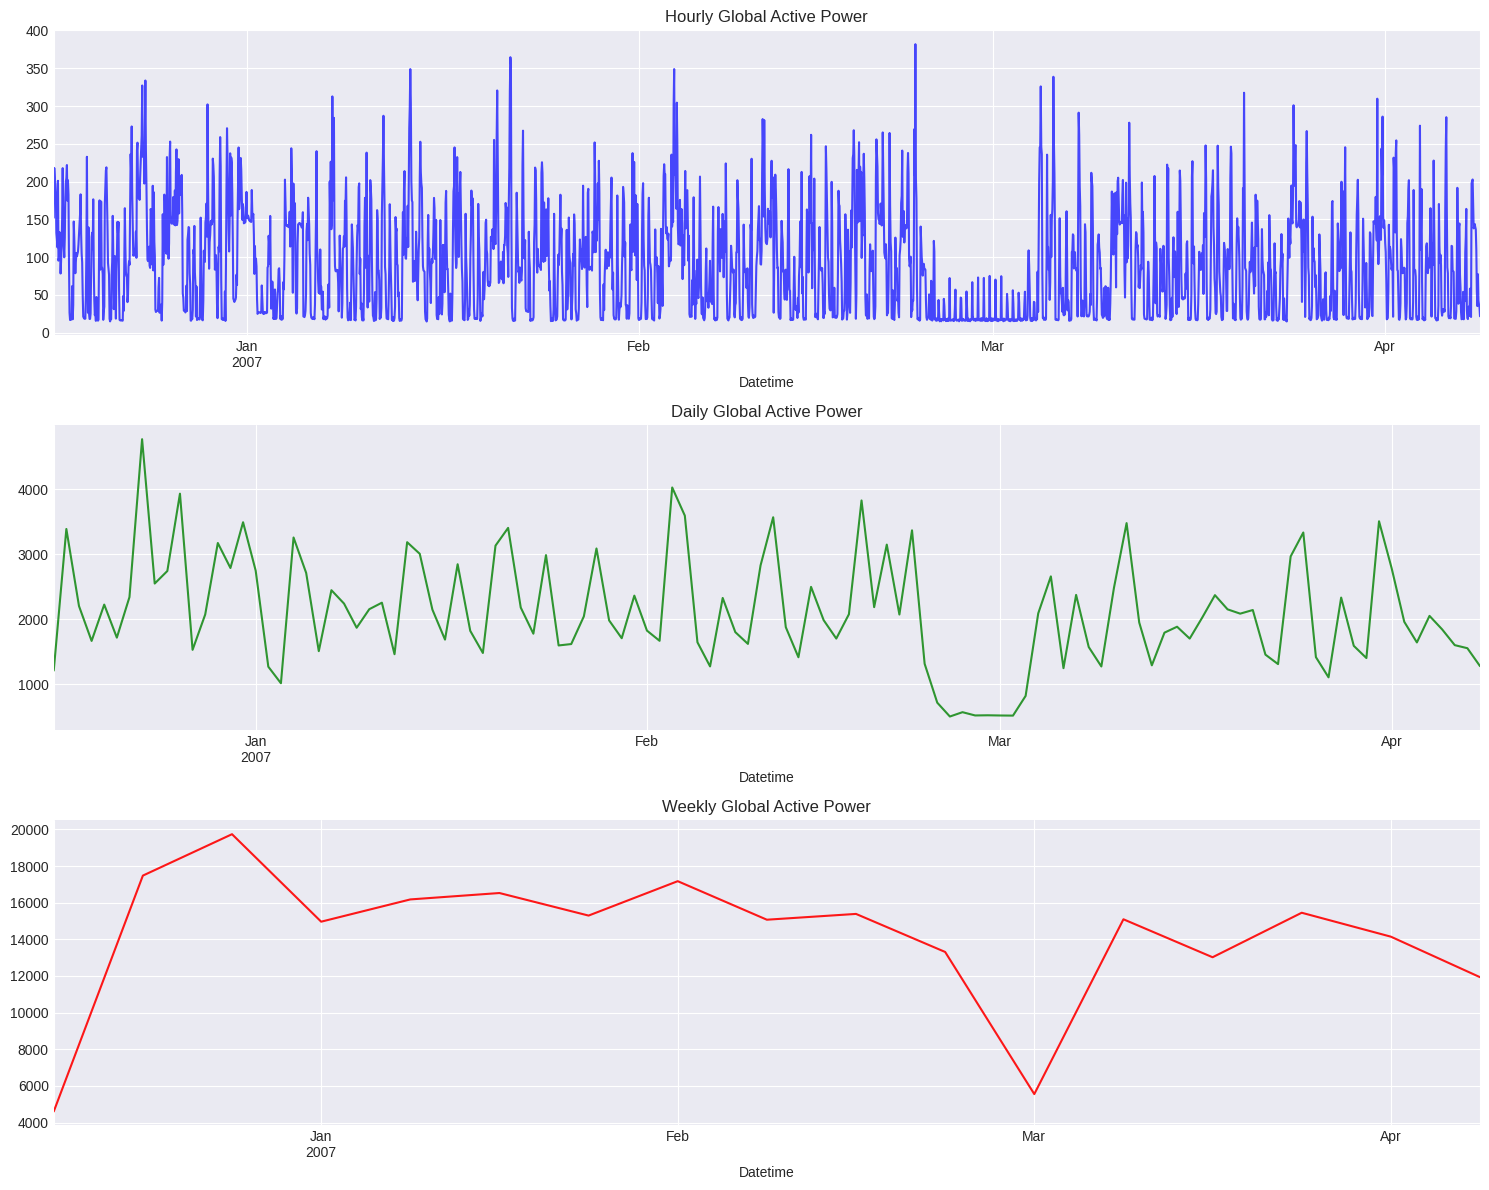

In [13]:
# Cell 3: Time Series Structure
print("--- Phase 2: Time Series Structure Analysis ---")

# Time range
print(f"Start Date: {df.index.min()}")
print(f"End Date: {df.index.max()}")

# Time granularity
time_diff = df.index.to_series().diff().mode()[0]
print(f"Time Granularity: {time_diff}")

# Continuous vs missing timestamps
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='T')
missing_timestamps = expected_range.difference(df.index)
print(f"Missing Timestamps: {len(missing_timestamps)}")

# Resampling impact (Aggregating to handle large visualization)
df_hourly = df.resample('H').sum()
df_daily = df.resample('D').sum()
df_weekly = df.resample('W').sum()

# Visualizations
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)
df_hourly['Global_active_power'].plot(ax=axes[0], title='Hourly Global Active Power', color='blue', alpha=0.7)
df_daily['Global_active_power'].plot(ax=axes[1], title='Daily Global Active Power', color='green', alpha=0.8)
df_weekly['Global_active_power'].plot(ax=axes[2], title='Weekly Global Active Power', color='red', alpha=0.9)
plt.tight_layout()
plt.show()

--- Phase 3: Target Variable Analysis ---
Skewness: 1.3081
Kurtosis: 1.8987
Explanation: Positive skew indicates a right-tailed distribution (many low-consumption periods, fewer extreme peaks).


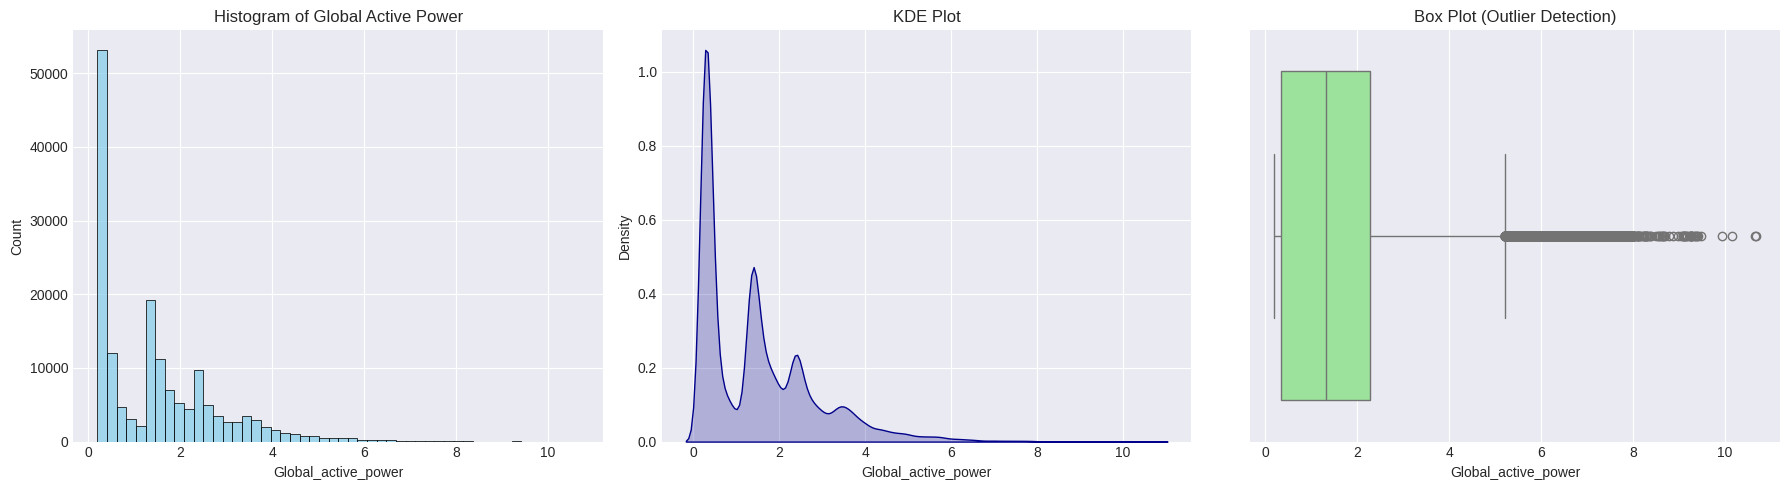

In [14]:
print("--- Phase 3: Target Variable Analysis ---")

target = 'Global_active_power'
target_data = df[target].dropna()

# Skewness and Kurtosis
print(f"Skewness: {target_data.skew():.4f}")
print(f"Kurtosis: {target_data.kurtosis():.4f}")
print("Explanation: Positive skew indicates a right-tailed distribution (many low-consumption periods, fewer extreme peaks).")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution/Histogram
sns.histplot(target_data, bins=50, kde=False, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Global Active Power')

# KDE Plot
sns.kdeplot(target_data, ax=axes[1], color='darkblue', fill=True)
axes[1].set_title('KDE Plot')

# Box Plot
sns.boxplot(x=target_data, ax=axes[2], color='lightgreen')
axes[2].set_title('Box Plot (Outlier Detection)')

plt.tight_layout()
plt.show()

--- Phase 4: Trend Analysis ---


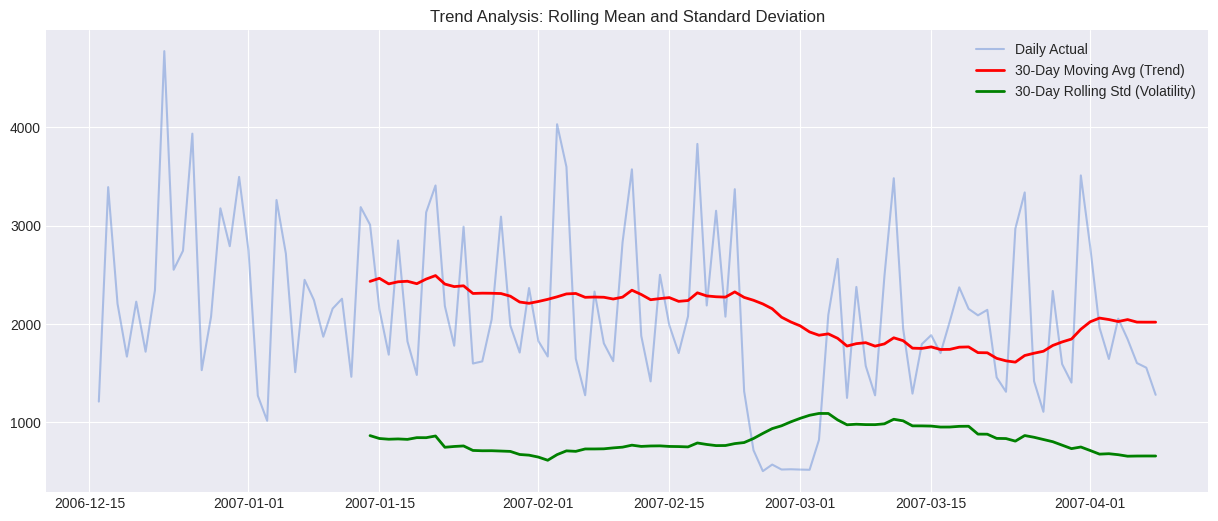

Explanation: If the red line moves up/down significantly, there is a trend. If the green line fluctuates heavily, variance is not constant (heteroscedasticity).


In [15]:
print("--- Phase 4: Trend Analysis ---")
# Using daily data to see macro trends clearly without noise
df_daily_target = df_daily['Global_active_power'].dropna()

plt.figure(figsize=(15, 6))
plt.plot(df_daily_target.index, df_daily_target, label='Daily Actual', alpha=0.4)
plt.plot(df_daily_target.rolling(window=30).mean(), label='30-Day Moving Avg (Trend)', color='red', linewidth=2)
plt.plot(df_daily_target.rolling(window=30).std(), label='30-Day Rolling Std (Volatility)', color='green', linewidth=2)
plt.title('Trend Analysis: Rolling Mean and Standard Deviation')
plt.legend()
plt.show()
print("Explanation: If the red line moves up/down significantly, there is a trend. If the green line fluctuates heavily, variance is not constant (heteroscedasticity).")

--- Phase 5: Seasonality Analysis ---


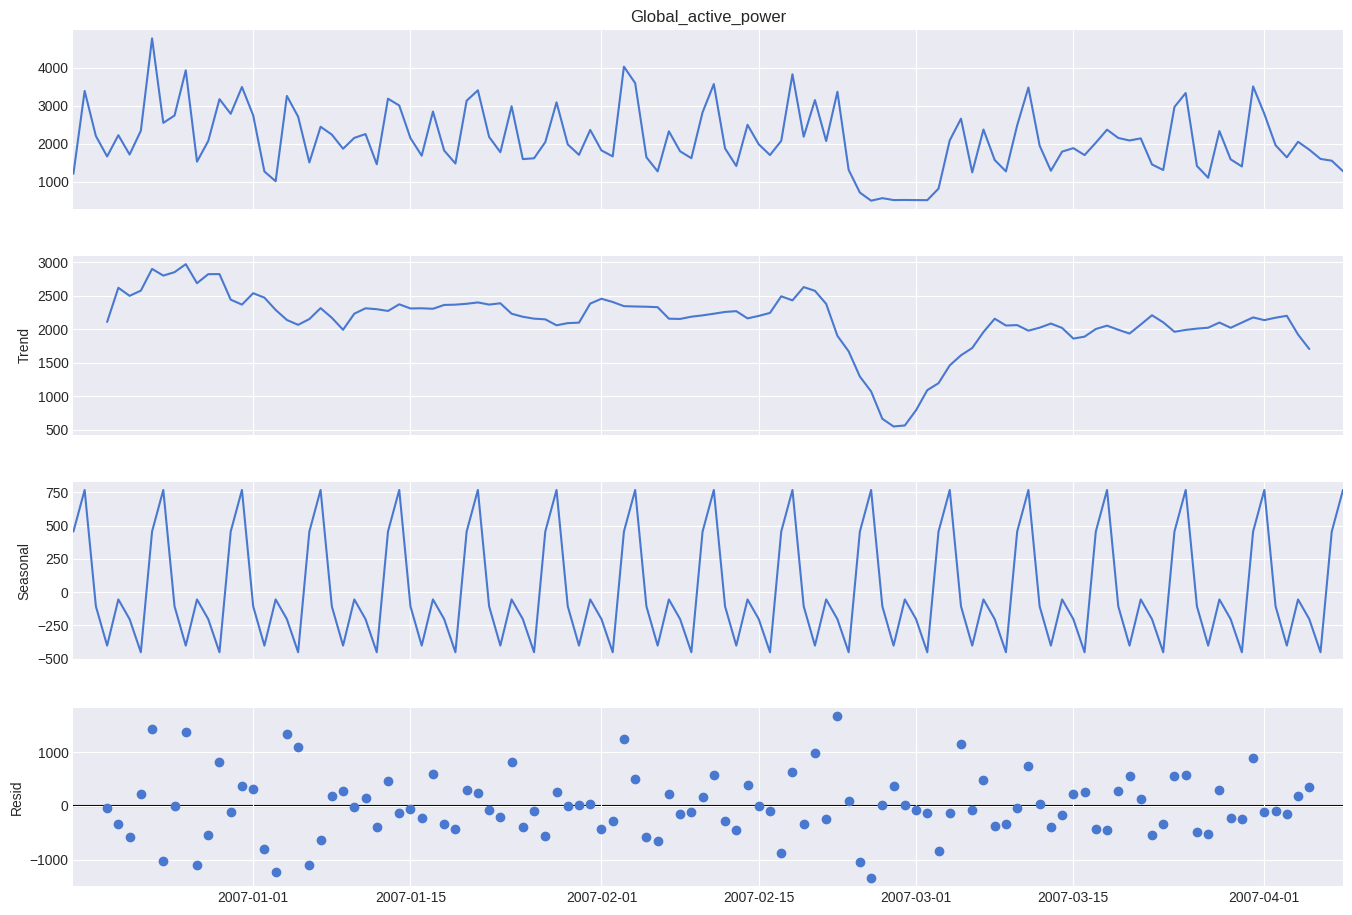

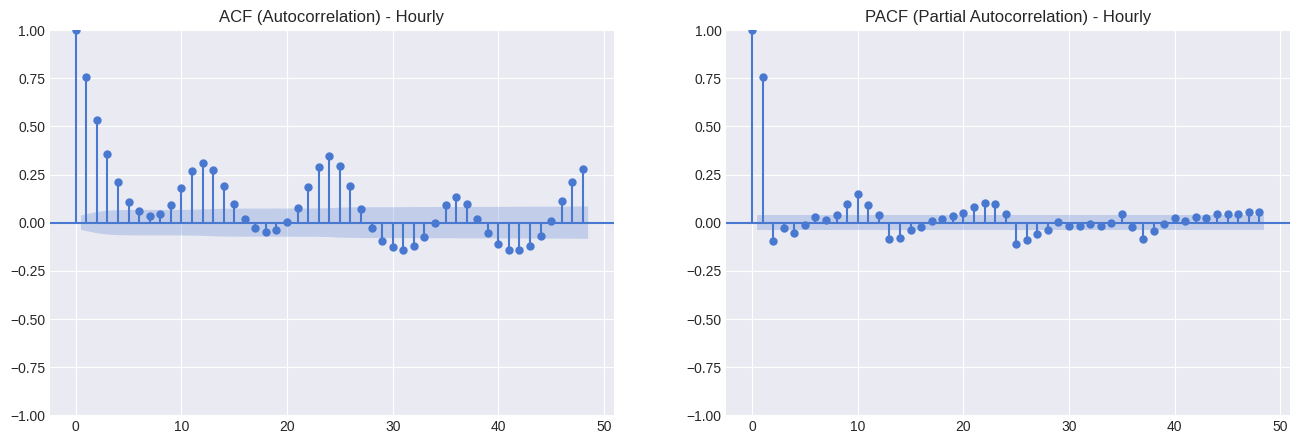

Explanation: Peaks at lags 24, 48 in ACF indicate strong daily seasonality.


In [16]:

# Cell 6: Seasonality Analysis
print("--- Phase 5: Seasonality Analysis ---")

# Seasonal Decomposition on Daily Data
decomposition = seasonal_decompose(df_daily_target.dropna(), model='additive', period=7) # Weekly seasonality on daily data
fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.show()
plt.close(fig) # Explicitly close the figure to release resources

# ACF and PACF on Hourly data (to see daily patterns)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df_hourly['Global_active_power'].dropna(), lags=48, ax=axes[0], title='ACF (Autocorrelation) - Hourly')
plot_pacf(df_hourly['Global_active_power'].dropna(), lags=48, ax=axes[1], title='PACF (Partial Autocorrelation) - Hourly')
plt.show()
print("Explanation: Peaks at lags 24, 48 in ACF indicate strong daily seasonality.")

--- Phase 6: Correlation Analysis ---


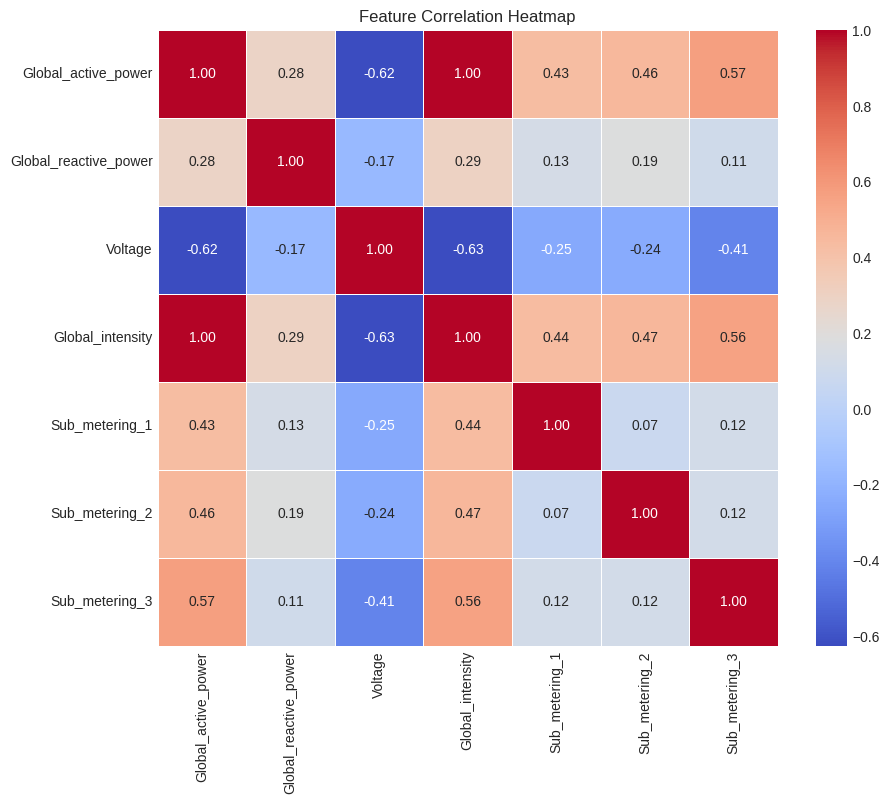

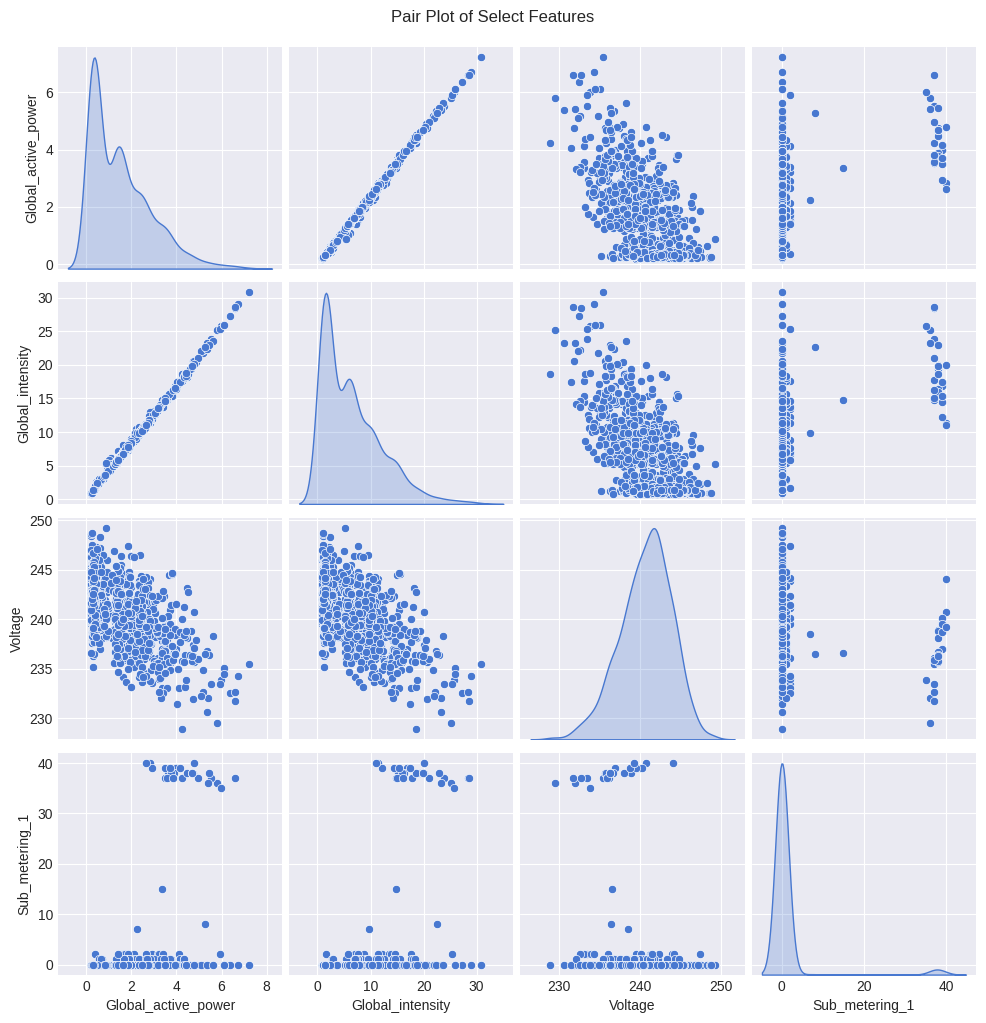

Explanation: Global_active_power and Global_intensity usually have a correlation near 1.0 (perfectly linear). Voltage may show weak negative correlation.


In [17]:
# Cell 7: Correlation Analysis
print("--- Phase 6: Correlation Analysis ---")

corr_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Pairplot (Using a small sample for performance)
sample_df = df.dropna().sample(1000)
sns.pairplot(sample_df[['Global_active_power', 'Global_intensity', 'Voltage', 'Sub_metering_1']], diag_kind='kde')
plt.suptitle('Pair Plot of Select Features', y=1.02)
plt.show()
print("Explanation: Global_active_power and Global_intensity usually have a correlation near 1.0 (perfectly linear). Voltage may show weak negative correlation.")

--- Phase 7: Lag Analysis ---


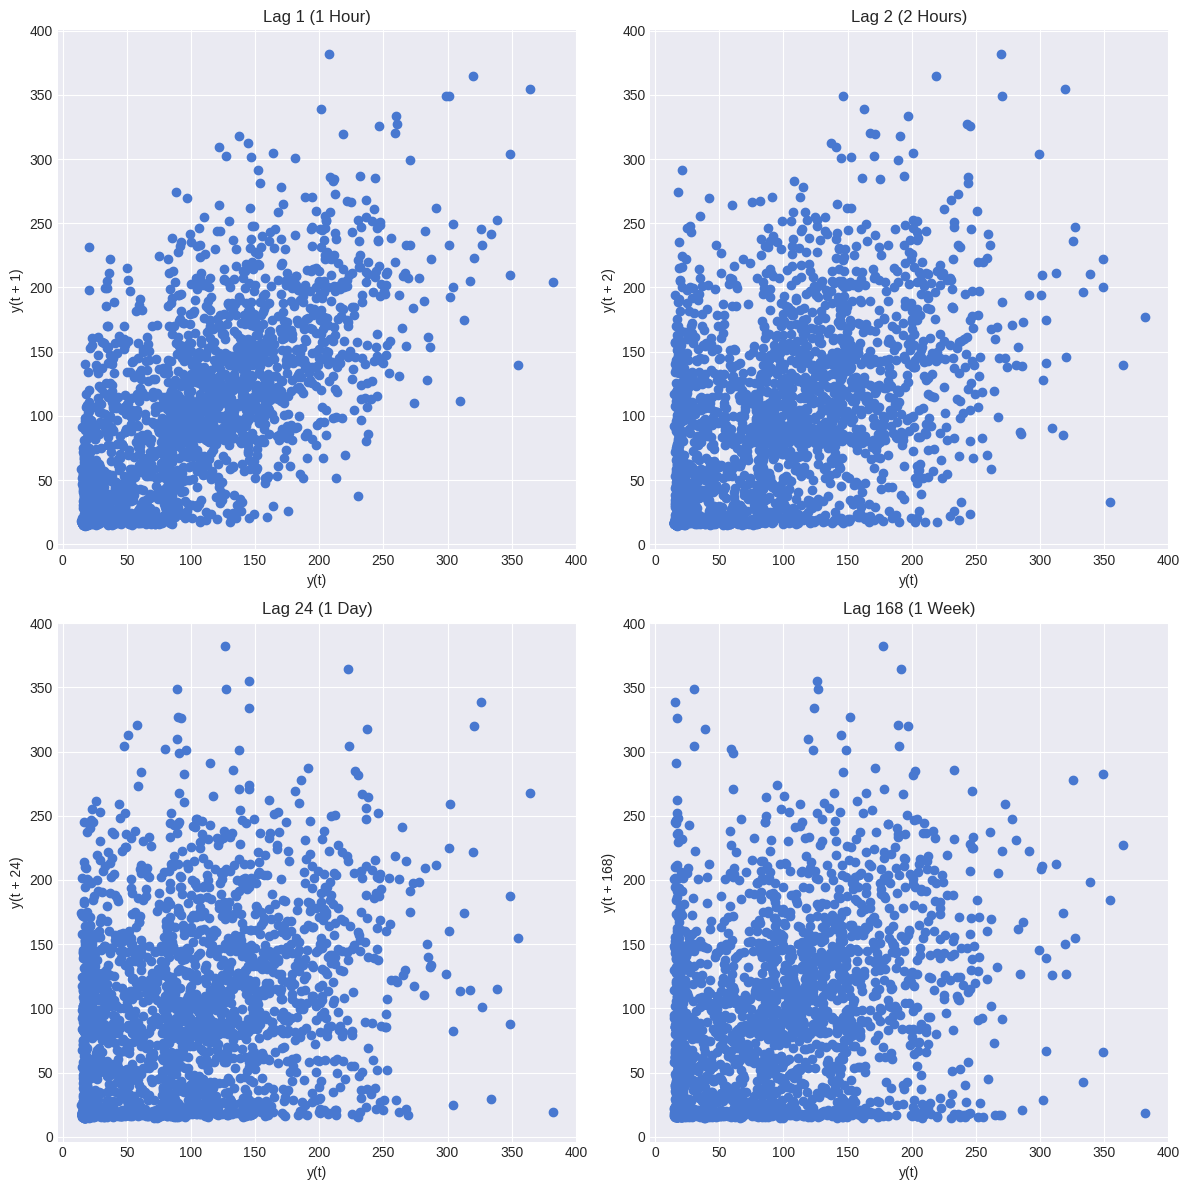

Explanation: Strong linear shapes indicate that past consumption is a great predictor for future consumption. Lag 24 usually shows a strong relationship.


In [18]:
# Cell 8: Lag Analysis
print("--- Phase 7: Lag Analysis ---")

# We use hourly data to check lags
hourly_target = df_hourly['Global_active_power'].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
pd.plotting.lag_plot(hourly_target, lag=1, ax=axes[0, 0])
axes[0, 0].set_title('Lag 1 (1 Hour)')

pd.plotting.lag_plot(hourly_target, lag=2, ax=axes[0, 1])
axes[0, 1].set_title('Lag 2 (2 Hours)')

pd.plotting.lag_plot(hourly_target, lag=24, ax=axes[1, 0])
axes[1, 0].set_title('Lag 24 (1 Day)')

pd.plotting.lag_plot(hourly_target, lag=168, ax=axes[1, 1])
axes[1, 1].set_title('Lag 168 (1 Week)')

plt.tight_layout()
plt.show()
print("Explanation: Strong linear shapes indicate that past consumption is a great predictor for future consumption. Lag 24 usually shows a strong relationship.")

In [19]:

# Cell 9: Stationarity Test
print("--- Phase 8: Stationarity Test ---")

# Test on daily data for speed
daily_clean = df_daily_target.dropna()

print("1. Augmented Dickey-Fuller (ADF) Test:")
adf_result = adfuller(daily_clean)
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')
print("Conclusion:", "Stationary (Reject Null)" if adf_result[1] < 0.05 else "Non-Stationary (Fail to Reject Null)")

print("\n2. KPSS Test:")
kpss_result = kpss(daily_clean, regression='c', nlags="auto")
print(f'KPSS Statistic: {kpss_result[0]:.4f}')
print(f'p-value: {kpss_result[1]:.4f}')
print("Conclusion:", "Non-Stationary (Reject Null)" if kpss_result[1] < 0.05 else "Stationary (Fail to Reject Null)")

--- Phase 8: Stationarity Test ---
1. Augmented Dickey-Fuller (ADF) Test:
ADF Statistic: -2.7911
p-value: 0.0596
Conclusion: Non-Stationary (Fail to Reject Null)

2. KPSS Test:
KPSS Statistic: 0.6909
p-value: 0.0144
Conclusion: Non-Stationary (Reject Null)


In [20]:
# Cell 10: Outlier Analysis
print("--- Phase 9: Outlier Analysis ---")

# Calculate IQR
Q1 = df['Global_active_power'].quantile(0.25)
Q3 = df['Global_active_power'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['Global_active_power'] < lower_bound) | (df['Global_active_power'] > upper_bound)]
print(f"Number of outliers (IQR method): {len(outliers_iqr)} ({(len(outliers_iqr)/len(df))*100:.2f}%)")

# Z-Score Method
z_scores = (df['Global_active_power'] - df['Global_active_power'].mean()) / df['Global_active_power'].std()
outliers_z = df[np.abs(z_scores) > 3]
print(f"Number of outliers (Z-score > 3): {len(outliers_z)}")

print("\nExplanation: In energy consumption, 'outliers' are often true peaks (turning on AC/Heater), not sensor errors. Domain knowledge is required before capping them.")

--- Phase 9: Outlier Analysis ---
Number of outliers (IQR method): 2806 (1.73%)
Number of outliers (Z-score > 3): 2268

Explanation: In energy consumption, 'outliers' are often true peaks (turning on AC/Heater), not sensor errors. Domain knowledge is required before capping them.


--- Phase 10: Anomaly Detection ---


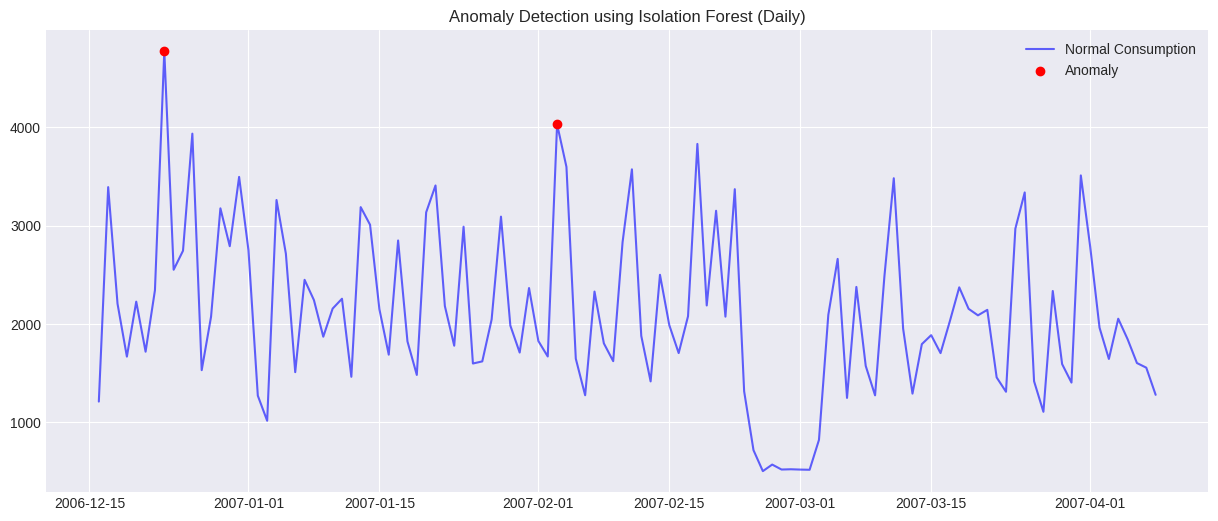

In [21]:
# Cell 11: Anomaly Detection
print("--- Phase 10: Anomaly Detection ---")

# Using Isolation Forest on a daily resampled subset to find anomalous days
iso_forest = IsolationForest(contamination=0.01, random_state=42)
df_daily_clean = df_daily.dropna()
df_daily_clean['Anomaly'] = iso_forest.fit_predict(df_daily_clean[['Global_active_power']])

plt.figure(figsize=(15, 6))
plt.plot(df_daily_clean.index, df_daily_clean['Global_active_power'], label='Normal Consumption', color='blue', alpha=0.6)
anomalies = df_daily_clean[df_daily_clean['Anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['Global_active_power'], color='red', label='Anomaly', zorder=5)
plt.title('Anomaly Detection using Isolation Forest (Daily)')
plt.legend()
plt.show()

--- Phase 11: Feature Importance Analysis ---


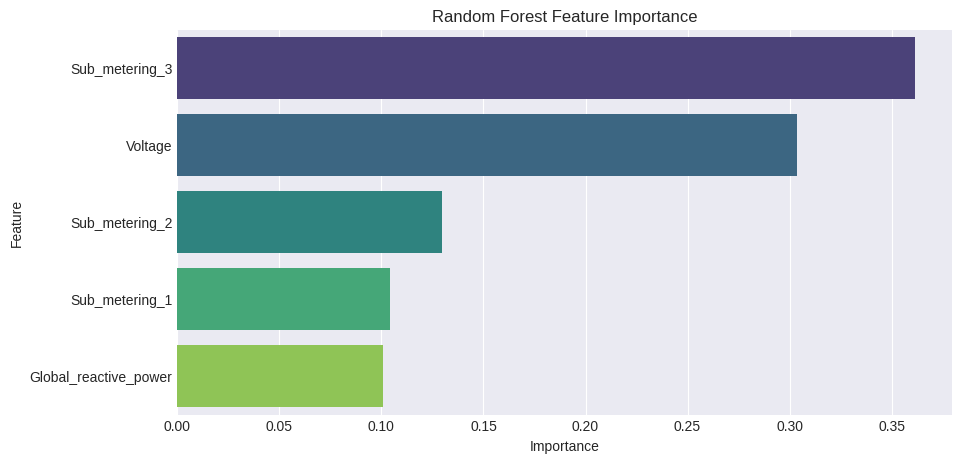

In [22]:
# Cell 12: Feature Importance
print("--- Phase 11: Feature Importance Analysis ---")

# Prepare data: Drop NaNs and the perfectly correlated Global_intensity
ml_df = df.dropna().drop('Global_intensity', axis=1).sample(50000) # Sampled for memory
X = ml_df.drop('Global_active_power', axis=1)
y = ml_df['Global_active_power']

rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.show()

--- Phase 12: Visualization Dashboard ---


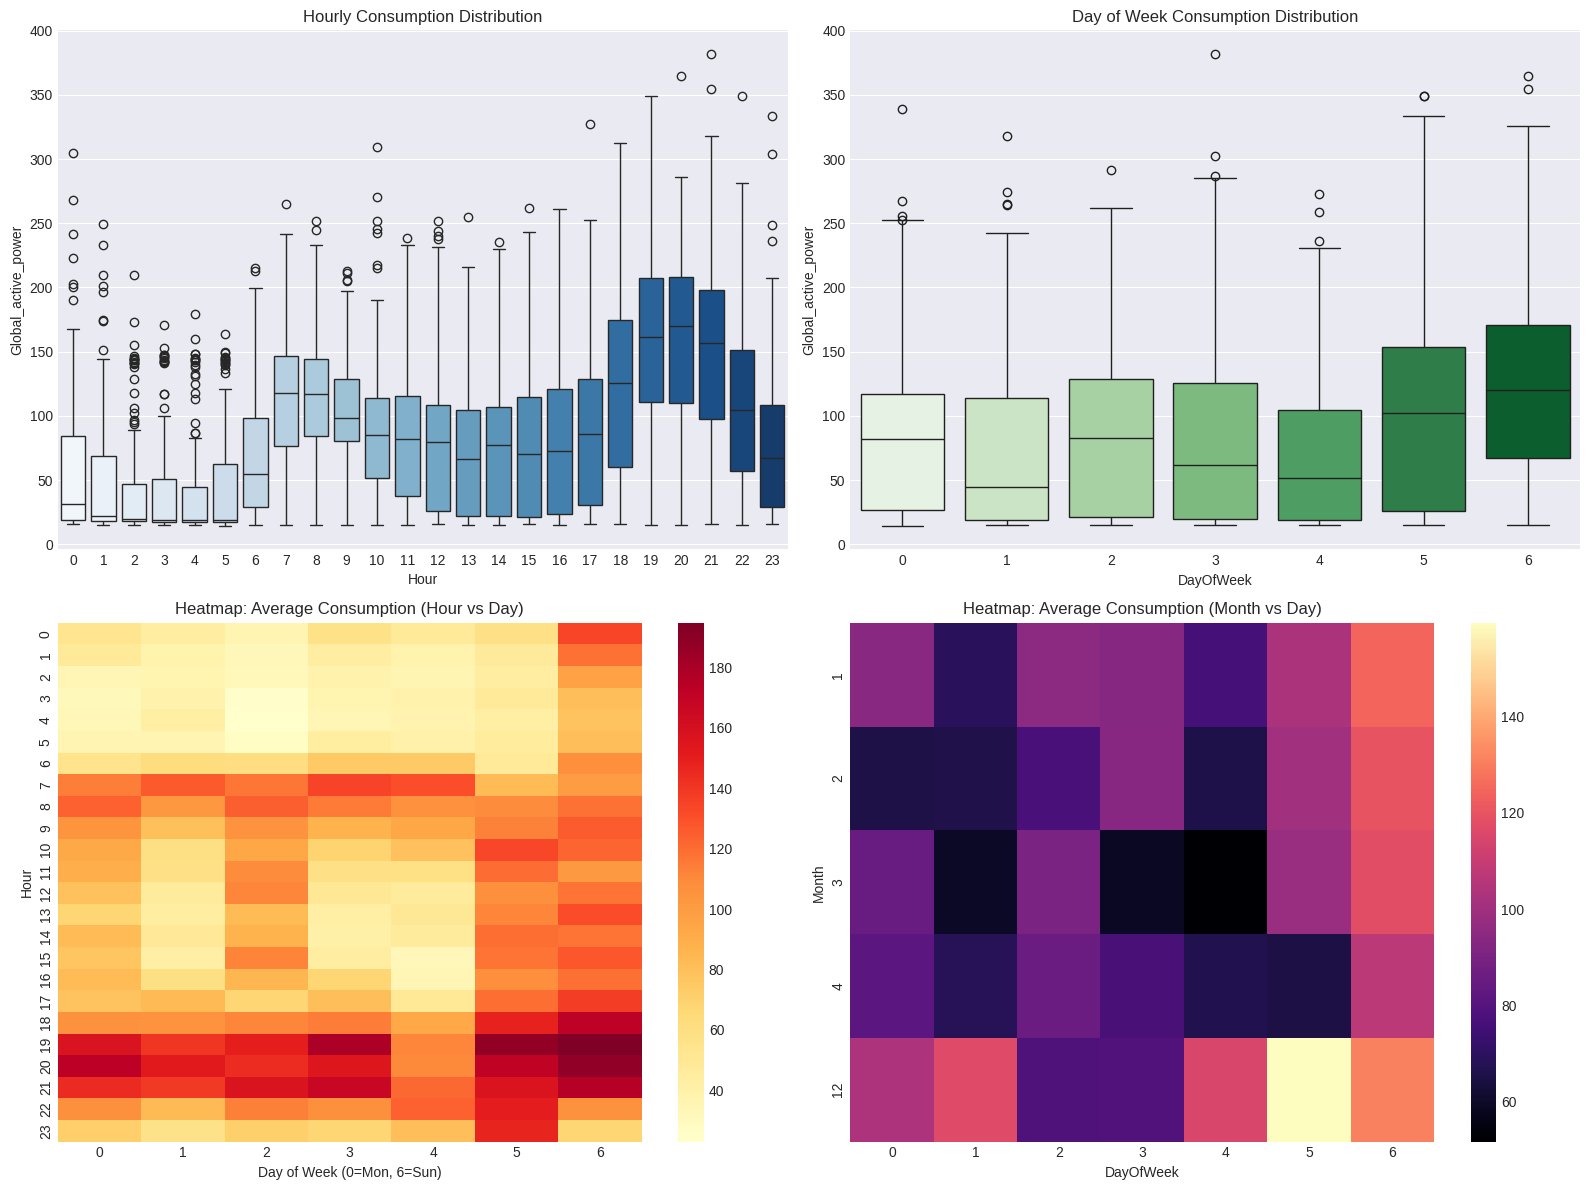

In [23]:
# Cell 13: Visualization Dashboard Elements
print("--- Phase 12: Visualization Dashboard ---")

# Extract temporal features
df_dash = df_hourly.copy()
df_dash['Hour'] = df_dash.index.hour
df_dash['DayOfWeek'] = df_dash.index.dayofweek
df_dash['Month'] = df_dash.index.month

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Hour vs Consumption
sns.boxplot(x='Hour', y='Global_active_power', data=df_dash, ax=axes[0, 0], palette='Blues')
axes[0, 0].set_title('Hourly Consumption Distribution')

# Day vs Consumption (0=Mon, 6=Sun)
sns.boxplot(x='DayOfWeek', y='Global_active_power', data=df_dash, ax=axes[0, 1], palette='Greens')
axes[0, 1].set_title('Day of Week Consumption Distribution')

# Heatmap: Hour vs Day
pivot_hour_day = df_dash.pivot_table(values='Global_active_power', index='Hour', columns='DayOfWeek', aggfunc='mean')
sns.heatmap(pivot_hour_day, cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('Heatmap: Average Consumption (Hour vs Day)')
axes[1, 0].set_xlabel('Day of Week (0=Mon, 6=Sun)')

# Heatmap: Month vs Day
pivot_month_day = df_dash.pivot_table(values='Global_active_power', index='Month', columns='DayOfWeek', aggfunc='mean')
sns.heatmap(pivot_month_day, cmap='magma', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap: Average Consumption (Month vs Day)')

plt.tight_layout()
plt.show()

In [24]:
"""
PROJECT 9: Energy Consumption Forecasting
Dataset: UCI Household Electric Power Consumption
Models: Linear Regression, Decision Tree, Random Forest
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# STEP 1: Load & Preprocess Data
# ─────────────────────────────────────────────

print("📥 Loading dataset...")

# Load dataset (semicolon-separated, '?' as missing values)
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)

# Use only first 50,000 rows for speed
df = df.head(50000)

print(f"   Loaded {len(df)} rows.")

# Combine Date and Time into a single datetime column
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df = df.drop(columns=['Date', 'Time'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Convert all power columns to numeric
power_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
df[power_cols] = df[power_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows with missing target value
df = df.dropna(subset=['Global_active_power'])

print(f"   After cleaning: {len(df)} rows.")

# ─────────────────────────────────────────────
# STEP 2: Feature Engineering
# ─────────────────────────────────────────────

print("\n🔧 Engineering features...")

# Extract time-based features
df['hour']       = df['Datetime'].dt.hour
df['dayofweek']  = df['Datetime'].dt.dayofweek   # 0=Monday
df['month']      = df['Datetime'].dt.month
df['dayofmonth'] = df['Datetime'].dt.day
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# Lag features (previous 1 and 2 readings = 1 min and 2 min ago)
df['lag_1'] = df['Global_active_power'].shift(1)
df['lag_2'] = df['Global_active_power'].shift(2)

# Rolling mean (last 10 readings)
df['rolling_mean_10'] = df['Global_active_power'].shift(1).rolling(10).mean()

# Drop rows with NaN introduced by lag/rolling
df = df.dropna().reset_index(drop=True)

# ─────────────────────────────────────────────
# STEP 3: Define Features & Target
# ─────────────────────────────────────────────

feature_cols = [
    'hour', 'dayofweek', 'month', 'dayofmonth', 'is_weekend',
    'lag_1', 'lag_2', 'rolling_mean_10',
    'Voltage', 'Global_intensity',
    'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

target_col = 'Global_active_power'

X = df[feature_cols]
y = df[target_col]

# ─────────────────────────────────────────────
# STEP 4: Time-Based Train/Test Split (no shuffle)
# ─────────────────────────────────────────────

print("\n✂️  Splitting data (80% train / 20% test)...")

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"   Train size: {len(X_train)} | Test size: {len(X_test)}")

# ─────────────────────────────────────────────
# STEP 5: Train Models
# ─────────────────────────────────────────────

print("\n🤖 Training models...")

models = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=20, max_depth=8,
                                                   random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    print(f"   → {name}...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results[name] = {'model': model, 'preds': preds, 'MAE': mae, 'RMSE': rmse}
    print(f"      MAE={mae:.4f}  RMSE={rmse:.4f}")

# ─────────────────────────────────────────────
# STEP 6: Model Comparison Table
# ─────────────────────────────────────────────

print("\n📊 Model Performance Comparison:")
print("-" * 45)
print(f"{'Model':<22} {'MAE':>10} {'RMSE':>10}")
print("-" * 45)
for name, r in results.items():
    print(f"{name:<22} {r['MAE']:>10.4f} {r['RMSE']:>10.4f}")
print("-" * 45)

# Identify best model by RMSE
best_name = min(results, key=lambda n: results[n]['RMSE'])
print(f"\n🏆 Best Model: {best_name}")



📥 Loading dataset...
   Loaded 50000 rows.
   After cleaning: 49995 rows.

🔧 Engineering features...

✂️  Splitting data (80% train / 20% test)...
   Train size: 39988 | Test size: 9997

🤖 Training models...
   → Linear Regression...
      MAE=0.0392  RMSE=0.0640
   → Decision Tree...
      MAE=0.0392  RMSE=0.0676
   → Random Forest...
      MAE=0.0267  RMSE=0.0473

📊 Model Performance Comparison:
---------------------------------------------
Model                         MAE       RMSE
---------------------------------------------
Linear Regression          0.0392     0.0640
Decision Tree              0.0392     0.0676
Random Forest              0.0267     0.0473
---------------------------------------------

🏆 Best Model: Random Forest



📈 Generating plots...


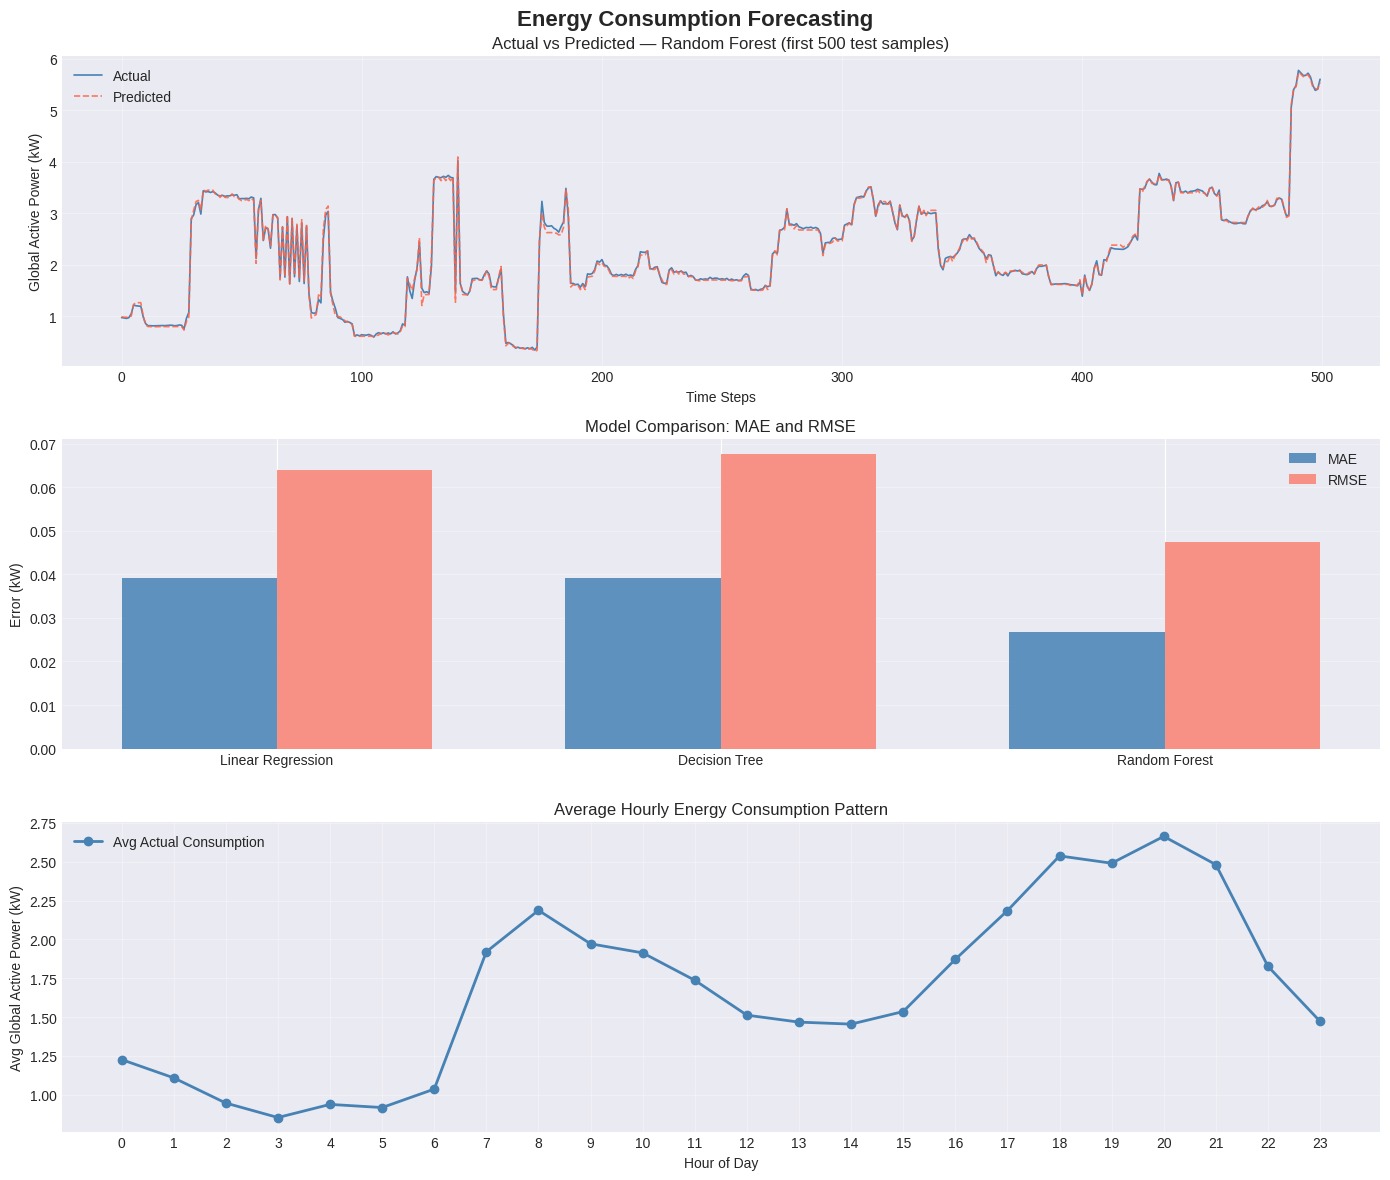


✅ Plot saved as 'energy_forecasting_results.png'


In [29]:
# ─────────────────────────────────────────────
# STEP 7: Visualizations
# ─────────────────────────────────────────────

print("\n📈 Generating plots...")

# --- Plot 1: Actual vs Predicted (best model, first 500 test points) ---
best_preds = results[best_name]['preds']
n_plot = 500
actual_sample = y_test.values[:n_plot]
pred_sample   = best_preds[:n_plot]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Energy Consumption Forecasting', fontsize=16, fontweight='bold')

# Time-series comparison
axes[0].plot(actual_sample, label='Actual',    color='steelblue', linewidth=1.2)
axes[0].plot(pred_sample,   label='Predicted', color='tomato',
             linewidth=1.2, linestyle='--', alpha=0.85)
axes[0].set_title(f'Actual vs Predicted — {best_name} (first {n_plot} test samples)')
axes[0].set_xlabel('Time Steps')
axes[0].set_ylabel('Global Active Power (kW)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: Model comparison bar chart ---
model_names = list(results.keys())
maes  = [results[n]['MAE']  for n in model_names]
rmses = [results[n]['RMSE'] for n in model_names]

x = np.arange(len(model_names))
width = 0.35
axes[1].bar(x - width/2, maes,  width, label='MAE',  color='steelblue', alpha=0.85)
axes[1].bar(x + width/2, rmses, width, label='RMSE', color='salmon',    alpha=0.85)
axes[1].set_title('Model Comparison: MAE and RMSE')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel('Error (kW)')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# --- Plot 3: Hourly average consumption trend ---
df['predicted_rf'] = np.nan
df.iloc[split_idx:split_idx + len(results['Random Forest']['preds']),
        df.columns.get_loc('predicted_rf')] = results['Random Forest']['preds']

hourly_actual = df.groupby('hour')['Global_active_power'].mean()
axes[2].plot(hourly_actual.index, hourly_actual.values,
             marker='o', color='steelblue', linewidth=2, label='Avg Actual Consumption')
axes[2].set_title('Average Hourly Energy Consumption Pattern')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Avg Global Active Power (kW)')
axes[2].set_xticks(range(0, 24))
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('energy_forecasting_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Plot saved as 'energy_forecasting_results.png'")

In [28]:
# ─────────────────────────────────────────────
# STEP 8: Feature Importance (Random Forest)
# ─────────────────────────────────────────────

print("\n🔍 Top Feature Importances (Random Forest):")
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)
print(importances.to_string())

print("\n✅ Done! All tasks completed successfully.")


🔍 Top Feature Importances (Random Forest):
Global_intensity    0.998889
lag_1               0.000510
Voltage             0.000197
hour                0.000115
lag_2               0.000074
dayofweek           0.000072
Sub_metering_3      0.000045
rolling_mean_10     0.000045
dayofmonth          0.000021
is_weekend          0.000020
Sub_metering_1      0.000008
Sub_metering_2      0.000002
month               0.000002

✅ Done! All tasks completed successfully.
